<h2 style = "color:green">INTRODUCTION

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The Indian technology job market is evolving rapidly, driven by growing demand for data, artificial intelligence, cloud computing, and software development professionals. This dataset provides a comprehensive view of the Indian tech hiring landscape in 2025, containing 23,201 real job listings collected from Naukri.com across major Indian cities and remote locations. It includes information on job roles, salary ranges, required skills, experience levels, work modes, company characteristics, and skill domains. Through Exploratory Data Analysis (EDA), this project aims to uncover hiring trends, salary patterns, skill demands, and geographical differences across various technology roles, providing valuable insights for job seekers, recruiters, and industry professionals.

<h2 style = "color:green">OBJECTIVES:


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>

<li>Analyze the distribution of tech job opportunities across different roles and cities.</li>
<li>Explore salary trends and identify factors influencing compensation.</li>
<li>Examine the demand for various technical skills and skill domains.
<li>Compare hiring patterns across Remote, Hybrid, and On-site work modes.
<li>Investigate experience-level requirements and opportunities for freshers and senior professionals.
<li>Identify cities and roles with the highest concentration of job openings.
<li>Generate actionable insights into the Indian tech job market to support career planning and workforce analysis.

</ul>
</div>

<h3 style = "color:green">1. Getting Ready with Data

In [2]:
import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

In [3]:
data = pl.read_csv('/home/kartika/Datasets/indian_tech_jobs_2026.csv')
data = data.to_pandas()


In [4]:
data.head()

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,2025-06-10,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21.0,False,False
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21.0,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,...,2025-06-10,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21.0,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21.0,False,False


In [5]:
data.tail()

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
23196,23197,Python Developer-Hyderabad,Infosys,3.5,Hybrid - Hyderabad,Hyderabad,Python Developer,2-7 Yrs,2.0,7.0,...,2025-06-10,Undisclosed,Junior (0-2 Yrs),False,Hyderabad,Data Science,0.0,1.0,False,False
23197,23198,Python Developer,Accufy,3.6,Hyderabad,Hyderabad,Python Developer,0-4 Yrs,0.0,4.0,...,2025-06-10,Undisclosed,Fresher,False,Hyderabad,Data Science,0.0,1.0,True,False
23198,23199,Walk in Interview Python Developer II Hyderabad,Tata Consultancy Services,3.3,"Hyderabad, Pune, Mumbai (All Areas)",Hyderabad,Python Developer,13 Jun,13.0,8.0,...,2025-06-10,Undisclosed,Lead/Architect (9+ Yrs),False,Hyderabad,Data Engineering,0.0,21.0,False,False
23199,23200,Python Developer,Mediamint,2.8,Hybrid - Hyderabad,Hyderabad,Python Developer,3-5 Yrs,3.0,5.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Data Science,0.0,0.0,False,False
23200,23201,Python Developer,CMM Level 5 IT Company,3.6,Hyderabad,Hyderabad,Python Developer,7-12 Yrs,7.0,12.0,...,2025-06-10,Senior (10-20 LPA),Senior (6-8 Yrs),False,Hyderabad,Data Science,13.0,1.0,False,False


In [6]:
data.drop(
    ['job_id', 'posted_date_raw', 'job_url',
      'data_source', 'scraped_at', 'salary_midpoint_lpa',
      'days_since_posted'], axis = 'columns', inplace = True
)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Dropped irrelevant columns.

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23201 entries, 0 to 23200
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_title            23201 non-null  object 
 1   company_name         23201 non-null  object 
 2   company_rating       23201 non-null  float64
 3   location             23201 non-null  object 
 4   scraped_city         23201 non-null  object 
 5   role_category        23201 non-null  object 
 6   experience_raw       23201 non-null  object 
 7   experience_min_yrs   23201 non-null  float64
 8   experience_max_yrs   23201 non-null  float64
 9   salary_raw           23201 non-null  object 
 10  salary_min_lpa       23201 non-null  float64
 11  salary_max_lpa       23201 non-null  float64
 12  salary_disclosed     23201 non-null  bool   
 13  skills_required      23201 non-null  object 
 14  skills_count         23201 non-null  int64  
 15  job_description      23201 non-null 

In [8]:
data.isnull().sum()

job_title              0
company_name           0
company_rating         0
location               0
scraped_city           0
role_category          0
experience_raw         0
experience_min_yrs     0
experience_max_yrs     0
salary_raw             0
salary_min_lpa         0
salary_max_lpa         0
salary_disclosed       0
skills_required        0
skills_count           0
job_description        0
work_mode              0
company_size_bucket    0
salary_tier            0
experience_tier        0
is_senior              0
primary_city           0
skill_domain           0
is_fresher_friendly    0
salary_negotiable      0
dtype: int64

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">No null values.

In [9]:
data.duplicated().sum()

np.int64(0)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">No duplicate values.

<div>

<h3 style = "color:green">2. Univariate Analysis

<h3 style = "color:green">2.1 Job Roles Distribution

In [10]:
data['role_category'].value_counts()

role_category
Data Scientist               6455
Data Analyst                 4729
Business Analyst             4505
Machine Learning Engineer    4004
Data Engineer                1922
Python Developer             1586
Name: count, dtype: int64

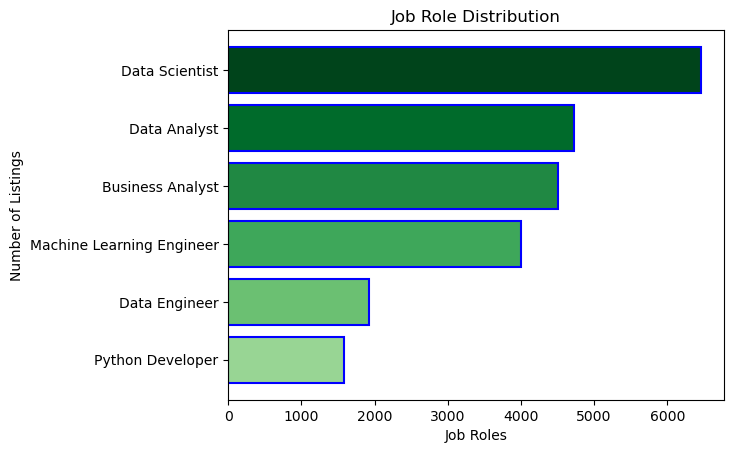

In [11]:
plt.barh(
    y = data['role_category'].value_counts().index,
    width = data['role_category'].value_counts().values,
    color = plt.cm.Greens(np.linspace(1,0.4,6)),
    linewidth = 1.5,
    edgecolor = 'blue',
)

plt.title("Job Role Distribution")
plt.xlabel('Job Roles')
plt.ylabel('Number of Listings')
plt.gca().invert_yaxis()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The job listing covers six  data related tech jobs out of which Data Scientist role is most listed. Data Analyst and Business Analyst have nearly same number of listings, followed by ML Engineer. Data Engineer and Python Developer have least number of listings.

<div>

<h3 style = "color:green">2.2 Cities Distribution

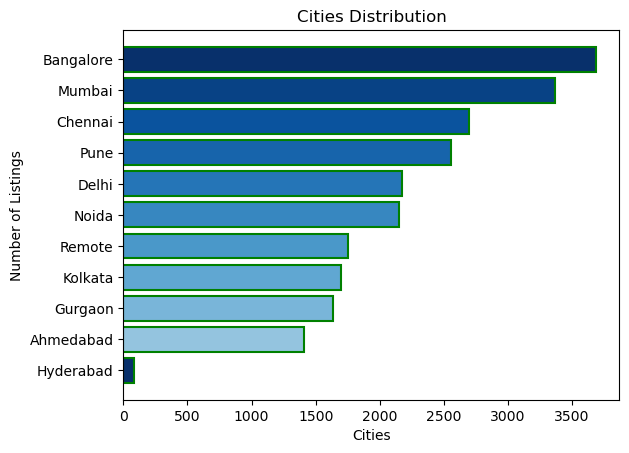

In [12]:
plt.barh(
    y = data['scraped_city'].value_counts().index,
    width = data['scraped_city'].value_counts().values,
    color = plt.cm.Blues(np.linspace(1,0.4,10)),
    linewidth = 1.5,
    edgecolor = 'green',
)

plt.title("Cities Distribution")
plt.xlabel('Cities')
plt.ylabel('Number of Listings')
plt.gca().invert_yaxis()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The job listings are from around ten different cities, out of which Bangalore has the most listings followed by Mumbai. Chennai and Pune have same number of listings, similary Delhi and Noida have same number of listing.

<div>

<h3 style = "color:green">2.3 Experience

In [13]:
data['experience'] = (data['experience_min_yrs']+data['experience_max_yrs'])/2

In [14]:
data['experience'].describe()

count    23201.000000
mean         5.982070
std          3.344859
min          0.000000
25%          3.500000
50%          6.000000
75%          7.500000
max         26.000000
Name: experience, dtype: float64

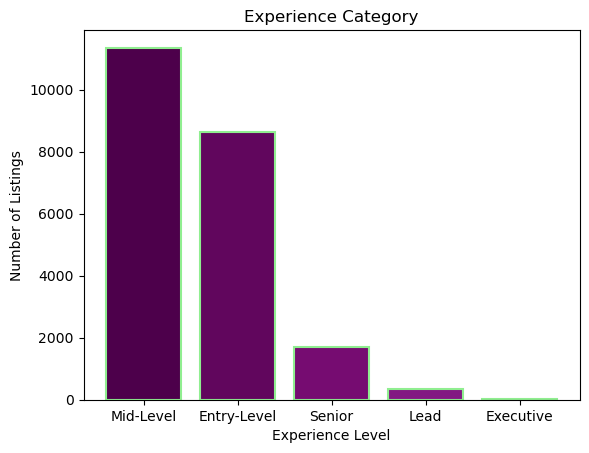

In [15]:
bins = [0, 5, 10, 15, 20, 27]
labels = ['Entry-Level', 'Mid-Level', 'Senior', 'Lead', 'Executive']

data['experience_category'] = pd.cut(data['experience'], bins = bins, labels = labels)

plt.bar(
    x = data['experience_category'].value_counts().index,
    height = data['experience_category'].value_counts().values,
    color = plt.cm.BuPu(np.linspace(1, 0.8, 5 )),
    linewidth = 1.5,
    edgecolor = 'lightgreen'
)

plt.title('Experience Category')
plt.xlabel('Experience Level')
plt.ylabel('Number of Listings')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The job listings mainly features job roles with mid-level experience (5-10) years. It also features good percentage of listings for entry-level/freshers.

<div>

<h3 style = "color:green">2.4 Salary Distribution

In [16]:
salary_data = data.loc[data['salary_disclosed'] == True].copy()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Approximately 88% of job listings do not disclose salary information. Therefore, the analysis is performed on the remaining 12% of listings where salary details are available, which have been filtered into a separate dataframe (salary_data).

In [17]:
salary_data['average_salary'] = (salary_data['salary_min_lpa']+salary_data['salary_max_lpa'])/2

salary_data['average_salary'].describe()

count    2768.000000
mean       15.320968
std        10.302717
min         0.000000
25%         7.500000
50%        14.000000
75%        21.500000
max        87.500000
Name: average_salary, dtype: float64

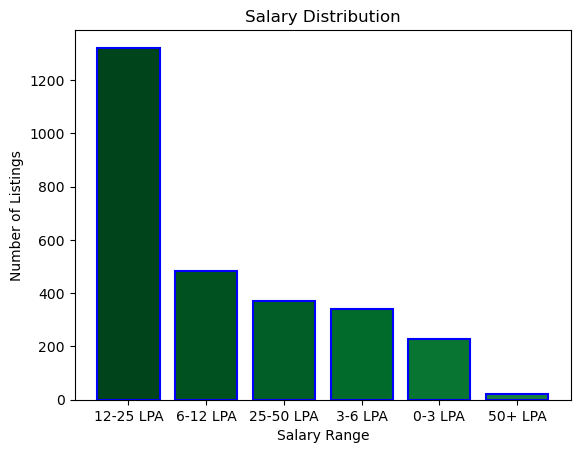

In [18]:
bins = [0, 3, 6, 12, 25, 50, 90]
labels = ['0-3 LPA', '3-6 LPA', '6-12 LPA', '12-25 LPA', '25-50 LPA', '50+ LPA']

salary_data['salary_category'] = pd.cut(salary_data['average_salary'], bins = bins ,labels = labels)

plt.bar(
    salary_data['salary_category'].value_counts().index, 
    height = salary_data['salary_category'].value_counts().values,
    color = plt.cm.Greens(np.linspace(1, 0.8, 6)),
    linewidth = 1.5,
    edgecolor ='blue'
)

plt.title('Salary Distribution')
plt.xlabel('Salary Range')
plt.ylabel('Number of Listings')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Most job listings offer 12-25 LPA salary, followed by 6-12 LPA.

<div>

<h3 style = "color:green">2.5 Top skills

In [19]:
data.loc[:, ['skills_required', 'skills_count', 'job_description']]

,skills_required,skills_count,job_description
0,"Computer science, Data analysis, data science,...",8,"Bachelor s degree in Statistics, Mathematics, ..."
1,"Basic, Data management, Business analytics, An...",8,"Requirements Analysis: Knowledge of tools, met..."
2,Not Available,0,Not Available
3,Not Available,0,Not Available
4,Not Available,0,Not Available
...,...,...,...
23196,"Django, Python, Pandas, Numpy, Flask, SQL",6,"MCA, MSc, MTech, Bachelor of Engineering, BCA,..."
23197,"Computer science, Backend, Version control, GI...",8,. Bachelors or Masters degree in Computer Scie...
23198,"Python, Pyspark, SQL, Development, Interviewing",5,Role - Python DeveloperExp. - 6+ yearsWalk in ...
23199,"AI/ML, API, Python Development, Python, Python...",8,We are looking for a skilled Python Developer ...


In [20]:
data['skills_list'] = data['skills_required'].str.split(',')

In [21]:
skills = data['skills_list'].explode()

In [22]:
top_skills = pd.Series(skills.value_counts().nlargest(10))
top_skills

skills_list
 Python                     2582
 Analytical                 2326
 SQL                        2241
 Machine learning           1909
 Artificial Intelligence    1641
 Data analysis              1612
 Data                       1611
 Analytics                  1560
Computer science            1497
 Agile                      1343
Name: count, dtype: int64

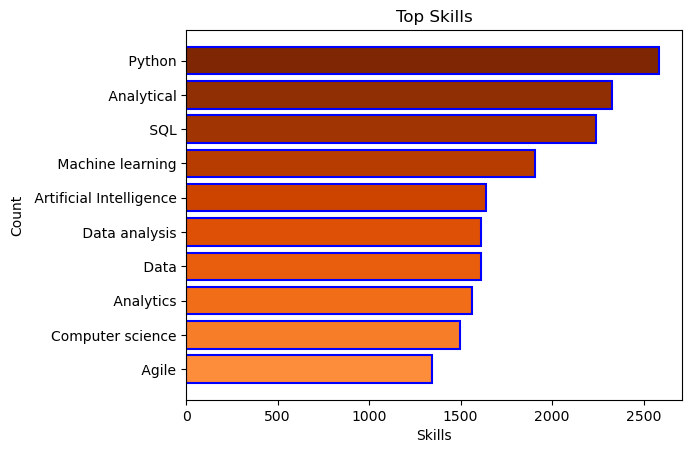

In [23]:
plt.barh(
    y = top_skills.index,
    width = top_skills.values,
    color = plt.cm.Oranges(np.linspace(1,0.5, 10)),
    linewidth = 1.5,
    edgecolor = 'blue'
)

plt.title('Top Skills')
plt.xlabel('Skills')
plt.ylabel('Count')
plt.gca().invert_yaxis()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Among various data skills, python stood out as the most demanded skill in the job listings. Followed by analytical skill and SQL.

<div>

<h3 style = "color:green">2.6 Work Mode


In [24]:
data['work_mode'].value_counts()

work_mode
On-site    18701
Hybrid      2347
Remote      2153
Name: count, dtype: int64

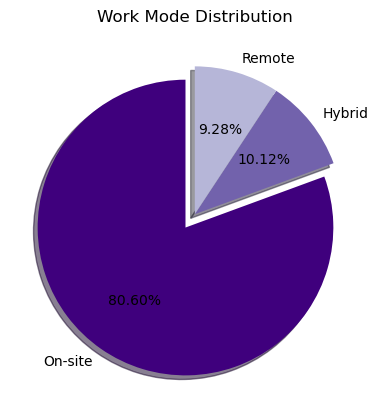

In [25]:
plt.pie(
    data['work_mode'].value_counts().values,
    labels = data['work_mode'].value_counts().index,
    colors = plt.cm.Purples(np.linspace(1,0.4,3)),
    startangle = 90,
    shadow = True,
    autopct = '%1.2f%%',
    explode = [0.11,0,0]
)

plt.title('Work Mode Distribution')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Among job listings, majority demand for on-site work. Remote and hybrid have nearly same percentage.

<div>

<h3 style = "color:green">2.7 Company Size Distribution

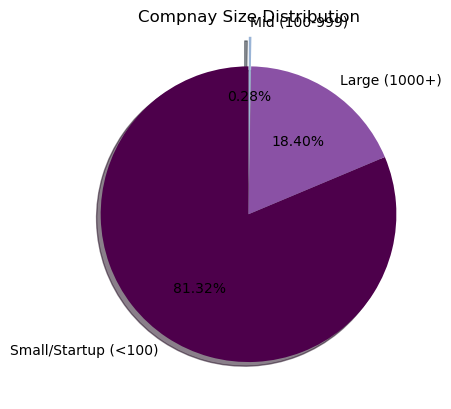

In [26]:
plt.pie(
    data['company_size_bucket'].value_counts().values,
    labels = data['company_size_bucket'].value_counts().index,
    colors = plt.cm.BuPu(np.linspace(1, 0.4, 3)),
    autopct = "%1.2f%%",
    startangle = 90,
    shadow = True,
    explode = [0, 0, 0.2]
)

plt.title('Compnay Size Distribution')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The job listings mainly features small/starups with less than 100 employees.

<div>

<h3 style = "color:green">3. Bivariate Analysis

<h3 style = "color:green">3.1 Job Roles vs City 

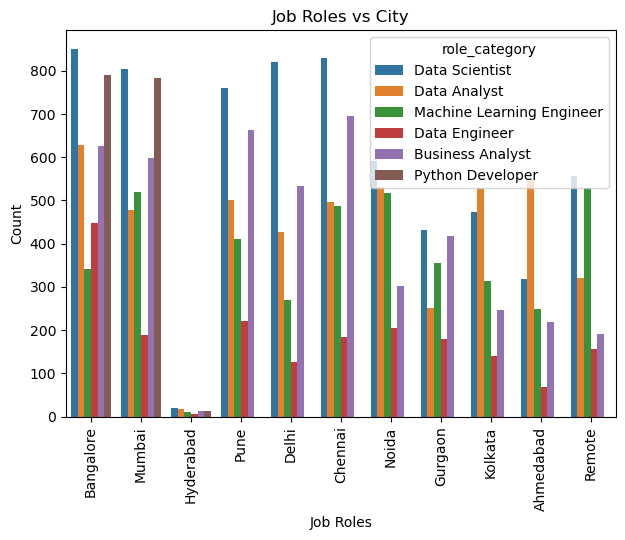

In [27]:
sns.countplot(
    data = data,
    x = 'scraped_city',
    hue = 'role_category',
    orient = 'v'
)

plt.title('Job Roles vs City')
plt.xlabel('Job Roles')
plt.ylabel('Count')
plt.tight_layout()
plt.xticks(rotation = 90)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The listings show, the demand for data scientists is highest among all top cities. Business analyst is second most demanded. Python developers are most demanded in Banglore and Mumbai which are the top cities in this job listings.

<div>

<h3 style = "color:green">3.2 Job Roles vs Major Skills Required

In [ ]:
skills_exploded = data['skills_required'].str.split(',').explode().str.strip()

skills_group = skills_exploded.groupby(level = 0).apply(list)

data['skills_per_role'] = skills_group
data['skills_per_role']

0        [Computer science, Data analysis, data science...
1        [Basic, Data management, Business analytics, A...
2                                          [Not Available]
3                                          [Not Available]
4                                          [Not Available]
                               ...                        
23196          [Django, Python, Pandas, Numpy, Flask, SQL]
23197    [Computer science, Backend, Version control, G...
23198    [Python, Pyspark, SQL, Development, Interviewing]
23199    [AI/ML, API, Python Development, Python, Pytho...
23200    [API, Python Development, Python, Python Frame...
Name: skills_per_role, Length: 23201, dtype: object

In [31]:
# group = data.groupby(
#     'role_category'
# )['skills_per_role'].value_counts()

In [ ]:
sns.countplot(
    data = data,
    x = 'skills_per'
)

In [28]:
print(data.columns)
print('\n')
print(salary_data.columns)

Index(['job_title', 'company_name', 'company_rating', 'location',
       'scraped_city', 'role_category', 'experience_raw', 'experience_min_yrs',
       'experience_max_yrs', 'salary_raw', 'salary_min_lpa', 'salary_max_lpa',
       'salary_disclosed', 'skills_required', 'skills_count',
       'job_description', 'work_mode', 'company_size_bucket', 'salary_tier',
       'experience_tier', 'is_senior', 'primary_city', 'skill_domain',
       'is_fresher_friendly', 'salary_negotiable', 'experience',
       'experience_category', 'skills_list'],
      dtype='object')


Index(['job_title', 'company_name', 'company_rating', 'location',
       'scraped_city', 'role_category', 'experience_raw', 'experience_min_yrs',
       'experience_max_yrs', 'salary_raw', 'salary_min_lpa', 'salary_max_lpa',
       'salary_disclosed', 'skills_required', 'skills_count',
       'job_description', 'work_mode', 'company_size_bucket', 'salary_tier',
       'experience_tier', 'is_senior', 'primary_city', 'skill_doma